In [1]:
#imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr, chi2_contingency, ttest_1samp

In [3]:
#Load the  Dataset

In [4]:
df = pd.read_csv("student_performance_updated_1000.csv")

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1000, 12)
Columns: ['StudentID', 'Name', 'Gender', 'AttendanceRate', 'StudyHoursPerWeek', 'PreviousGrade', 'ExtracurricularActivities', 'ParentalSupport', 'FinalGrade', 'Study Hours', 'Attendance (%)', 'Online Classes Taken']


,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


In [5]:
#Choose Dependent Variable + Basic Cleaning

In [6]:
dep_col = "FinalGrade"   # change ONLY if your column name is different

# ensure numeric + drop missing in dependent
df[dep_col] = pd.to_numeric(df[dep_col], errors="coerce")
df = df.dropna(subset=[dep_col])

print("Dependent variable:", dep_col)
print("Missing values (top):")
print(df.isna().sum().sort_values(ascending=False).head(10))

Dependent variable: FinalGrade
Missing values (top):
Gender                       47
StudyHoursPerWeek            47
ExtracurricularActivities    41
Attendance (%)               40
StudentID                    38
AttendanceRate               37
Name                         33
PreviousGrade                31
Online Classes Taken         23
ParentalSupport              22
dtype: int64


In [7]:
#Descriptive Function

In [8]:
def descriptive_stats(sample_df: pd.DataFrame, field: str) -> dict:
    s = pd.to_numeric(sample_df[field], errors="coerce").dropna()
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)

    return {
        "count": int(s.count()),
        "mean": float(s.mean()),
        "median": float(s.median()),
        "std": float(s.std(ddof=1)),
        "min": float(s.min()),
        "q1": float(q1),
        "q3": float(q3),
        "iqr": float(q3 - q1),
        "max": float(s.max()),
        "skew": float(s.skew())
    }

# test on full dataset
full_desc = descriptive_stats(df, dep_col)
full_desc

{'count': 960,
 'mean': 80.03020833333333,
 'median': 80.0,
 'std': 9.493652121996378,
 'min': 62.0,
 'q1': 72.0,
 'q3': 88.0,
 'iqr': 16.0,
 'max': 92.0,
 'skew': -0.5174010563628026}

In [9]:
#Random Sampling (n=150) + Output

In [10]:
SAMPLE_SIZE = 150

random_sample = df.sample(n=SAMPLE_SIZE, random_state=42)
rand_desc = descriptive_stats(random_sample, dep_col)

print("Random sample (n=150) descriptive stats:")
for k, v in rand_desc.items():
    print(f"{k:>8}: {v}")

Random sample (n=150) descriptive stats:
   count: 150
    mean: 79.64666666666666
  median: 80.0
     std: 9.57354903697218
     min: 62.0
      q1: 72.0
      q3: 88.0
     iqr: 16.0
     max: 92.0
    skew: -0.5325345874799368


In [11]:
#Systematic Sampling (n=150) + Output

In [12]:
# If StudentID exists, it’s best to sort by it for systematic sampling.
# If not, we will use the current row order.
id_col = "StudentID" if "StudentID" in df.columns else None

sys_df = df.copy()
if id_col:
    sys_df = sys_df.sort_values(by=id_col).reset_index(drop=True)
else:
    sys_df = sys_df.reset_index(drop=True)

k = len(sys_df) // SAMPLE_SIZE
if k < 1:
    k = 1

np.random.seed(42)
start = np.random.randint(0, k)

systematic_sample = sys_df.iloc[start::k].head(SAMPLE_SIZE)
sys_desc = descriptive_stats(systematic_sample, dep_col)

print(f"Systematic sample settings: k={k}, start={start}, size={len(systematic_sample)}")
print("\nSystematic sample descriptive stats:")
for k2, v in sys_desc.items():
    print(f"{k2:>8}: {v}")

Systematic sample settings: k=6, start=3, size=150

Systematic sample descriptive stats:
   count: 150
    mean: 80.55333333333333
  median: 85.0
     std: 9.089810407475381
     min: 62.0
      q1: 72.0
      q3: 88.0
     iqr: 16.0
     max: 92.0
    skew: -0.637014067643701


In [13]:
#Descriptive Statistics Report Table

In [14]:
desc_report = pd.DataFrame(
    [full_desc, rand_desc, sys_desc],
    index=["Population", "RandomSample150", "SystematicSample150"]
)

desc_report

,count,mean,median,std,min,q1,q3,iqr,max,skew
Population,960,80.030208,80.0,9.493652,62.0,72.0,88.0,16.0,92.0,-0.517401
RandomSample150,150,79.646667,80.0,9.573549,62.0,72.0,88.0,16.0,92.0,-0.532535
SystematicSample150,150,80.553333,85.0,9.089810,62.0,72.0,88.0,16.0,92.0,-0.637014


In [15]:
#Visualizations

In [16]:
#8A.Scatter plot

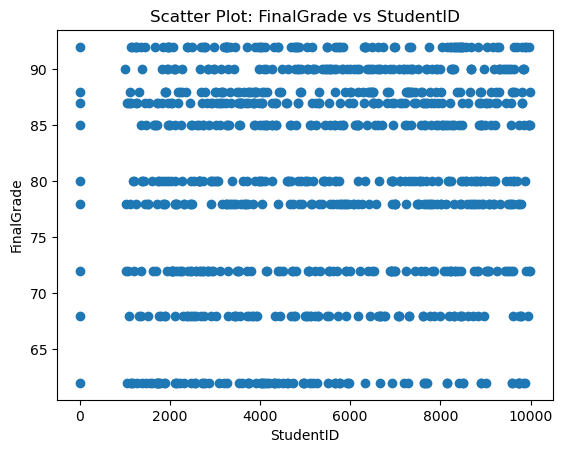

In [17]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != dep_col]
x_col = numeric_cols[0]  # you can replace with "AttendanceRate" etc.

plt.figure()
plt.scatter(df[x_col], df[dep_col])
plt.title(f"Scatter Plot: {dep_col} vs {x_col}")
plt.xlabel(x_col)
plt.ylabel(dep_col)
plt.show()

In [18]:
#8B.Box plot

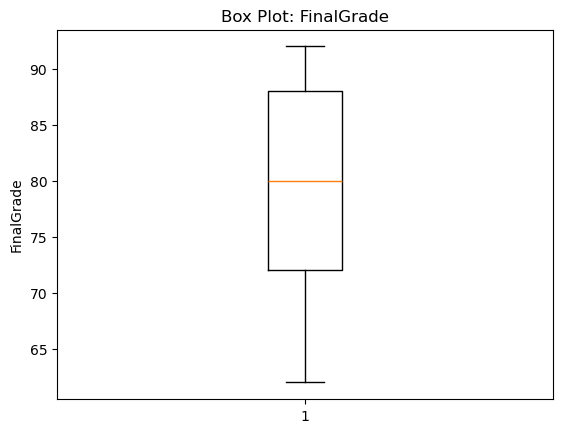

In [19]:
plt.figure()
plt.boxplot(df[dep_col].dropna())
plt.title(f"Box Plot: {dep_col}")
plt.ylabel(dep_col)
plt.show()

In [20]:
#8C. Histogram

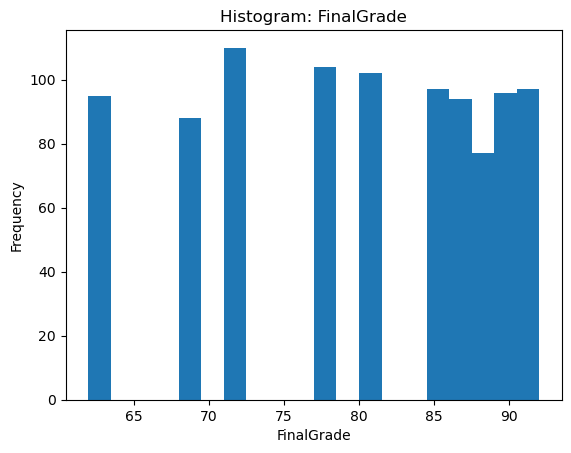

In [21]:
plt.figure()
plt.hist(df[dep_col].dropna(), bins=20)
plt.title(f"Histogram: {dep_col}")
plt.xlabel(dep_col)
plt.ylabel("Frequency")
plt.show()

In [22]:
#8D. Heat map (correlation heatmap)

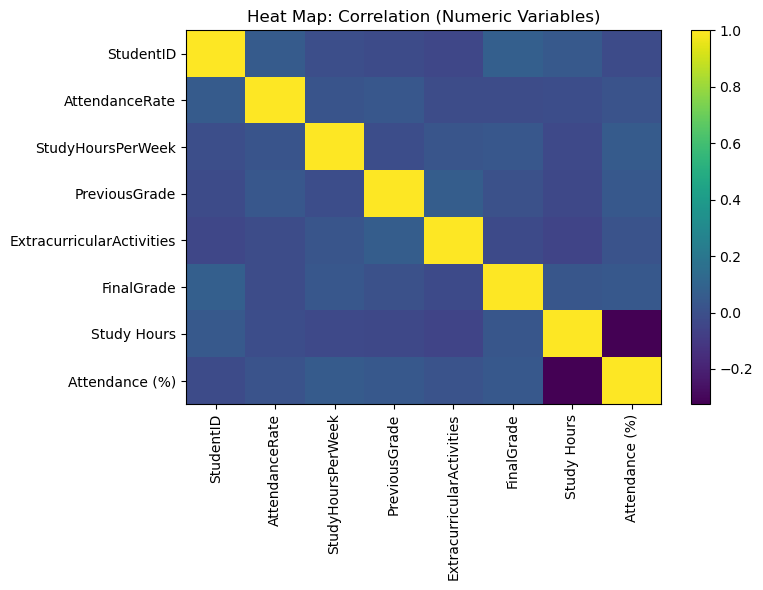

In [23]:
corr = df.select_dtypes(include=[np.number]).corr(numeric_only=True)

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.title("Heat Map: Correlation (Numeric Variables)")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.colorbar()
plt.tight_layout()
plt.show()

In [24]:
#Correlation Tests (Pearson + Spearman)

In [25]:
indep_num = x_col  # uses the same variable you used in scatter plot

temp = df[[indep_num, dep_col]].dropna()

r_p, p_p = pearsonr(temp[indep_num], temp[dep_col])
r_s, p_s = spearmanr(temp[indep_num], temp[dep_col])

print(f"Pearson correlation between {indep_num} and {dep_col}: r={r_p:.4f}, p-value={p_p:.6f}")
print(f"Spearman correlation between {indep_num} and {dep_col}: rho={r_s:.4f}, p-value={p_s:.6f}")

Pearson correlation between StudentID and FinalGrade: r=0.0783, p-value=0.017378
Spearman correlation between StudentID and FinalGrade: rho=0.0705, p-value=0.032196


In [26]:
#Chi-square (categorical vs binned FinalGrade)

In [27]:
cat_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

if len(cat_cols) == 0:
    print("No categorical columns found for chi-square.")
else:
    cat_col = cat_cols[0]  # replace with "Gender" or "ParentalSupport" if you want

    binned = pd.qcut(df[dep_col], q=3, labels=["Low", "Medium", "High"])
    contingency = pd.crosstab(df[cat_col], binned)

    chi2, p, dof, expected = chi2_contingency(contingency)

    print(f"Chi-square test between {cat_col} and binned {dep_col} (Low/Medium/High):")
    print("Chi2 =", chi2)
    print("p-value =", p)
    print("dof =", dof)
    print("\nContingency table:\n", contingency)

Chi-square test between Name and binned FinalGrade (Low/Medium/High):
Chi2 = 1851.0274598179276
p-value = 0.44964970700502377
dof = 1844

Contingency table:
 FinalGrade      Low  Medium  High
Name                             
Aaron Duarte      1       0     0
Aaron Walls       0       0     1
Abigail Ingram    0       0     1
Adam Blackwell    1       0     0
Adam Carlson      1       0     0
...             ...     ...   ...
William Wade      0       1     0
William Weber     0       1     0
William White     0       0     1
Yvonne Krueger    0       1     0
Zachary Daniel    1       0     0

[923 rows x 3 columns]


In [28]:
#One-sample T-test

In [29]:
mu = df[dep_col].mean()
sample_vals = random_sample[dep_col].dropna()

t_stat, p_val = ttest_1samp(sample_vals, popmean=mu)

print("One-sample t-test (Random sample vs population mean):")
print("Population mean (mu) =", round(mu, 4))
print("Sample mean =", round(sample_vals.mean(), 4))
print("t-statistic =", round(t_stat, 4))
print("p-value =", round(p_val, 6))

One-sample t-test (Random sample vs population mean):
Population mean (mu) = 80.0302
Sample mean = 79.6467
t-statistic = -0.4907
p-value = 0.624385
